# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(Bahadur Ali)_

**Roll Number:** _(023-24-0005)_

**GitHub Repository:** _()_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("telco_churn.csv")   # update path/filename if different


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_The primary business challenge is customer attrition (churn), and the telecommunications company needs to identify which clients are at high risk of canceling their services. Therefore, the target variable we need to predict is the `Churn` column, which contains 'Yes' or 'No' values indicating if a customer left._

**Answer 2:**
_Useful Predictors:_
_1. `tenure`: Customers who have been with the company longer usually show higher loyalty._
_2. `Contract`: Users on month-to-month plans lack commitment and are more prone to leaving._
_3. `MonthlyCharges`: Higher monthly bills might drive price-sensitive customers away._
_4. `InternetService`: The type of connection (e.g., Fiber optic vs. DSL) can heavily impact user satisfaction._
_5. `PaymentMethod`: Manual payment methods might reflect lower engagement compared to automatic billing._

_Useless Predictors:_
_1. `customerID`: This is just a randomly assigned unique string and holds no behavioral pattern for prediction._
_2. `gender`: A person's gender alone generally does not dictate their likelihood of staying or leaving the telecom service._

**Answer 3:**
_1. Is there a direct connection between expensive monthly bills and a higher customer drop-off rate?_
_2. Do customers who avoid long-term agreements (like 1-year or 2-year contracts) make up the majority of the churn?_

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [ ]:
# Task 4 — dataset shape, column names, data types
print("Shaped Data: ", df.shape)
print("\nNumerical Dataset: ", df.select_dtypes(include=[np.number]).columns.tolist())
print("\nCategorical Dataset: ", df.select_dtypes(include=['object', 'string']).columns.tolist())


Shaped Data:  (7043, 21)

Numerical Dataset:  ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical Dataset:  ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [ ]:
# Task 5 — identify identifier columns / wrong data types
print(df.dtypes)
print("\nSample Data: ")
display(df.head(5))

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Sample Data: 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Task 6 — unique values in 3 categorical columns
for col in ['Contract', 'InternetService' , 'PaymentMethod']:
    print(f" --- Unique values in {col} --- ")
    print(df[col].unique())
    print()

 --- Unique values in Contract --- 
<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

 --- Unique values in InternetService --- 
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

 --- Unique values in PaymentMethod --- 
<StringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str



**Observations (Part 2):**

_The data consists of 21 features across 7,043 customer records. Currently, only `SeniorCitizen`, `tenure`, and `MonthlyCharges` are recognized as numerical variables, while all other columns are formatted as text/objects. Notably, `TotalCharges` is saved as a string, which is an incorrect data type since it represents a financial amount and must be numeric. The `customerID` column serves merely as a distinct row label and offers no value for predictive modeling. Furthermore, even though `SeniorCitizen` is encoded with numbers (0 and 1), it actually functions as a binary category rather than a true continuous measurement. A review of categorical fields like `Contract`, `InternetService`, and `PaymentMethod` reveals well-structured, limited unique values (for instance, the Contract column only contains 'Month-to-month', 'One year', and 'Two year') without any spelling errors or case inconsistencies. Ultimately, the most significant data quality problem to address moving into Part 3 is the incorrect string format of the `TotalCharges` column._

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [ ]:
# Task 7 — missing values: count and percentage per column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_df = pd.DataFrame({'Missing Count':missing_count, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

              Missing Count  Percentage (%)
TotalCharges             11            0.16


In [ ]:
# Task 8 — duplicate rows vs duplicate IDs
duplicate_rows = df.duplicated().sum()
duplicate_ids = df['customerID'].duplicated().sum()

print(f"Full duplicate rows count: {duplicate_rows}")
print(f"Duplicate customerID count: {duplicate_ids}")


Full duplicate rows count: 0
Duplicate customerID count: 0


In [ ]:
# Task 9 — investigate a suspicious / invalid value
blank_total_charges = df[df['TotalCharges'].astype(str).str.strip() == ""]
print(f"Numbers of rows with blank in TotalCharges: {len(blank_total_charges)}")
display(blank_total_charges[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Numbers of rows with blank in TotalCharges: 0


,customerID,tenure,MonthlyCharges,TotalCharges


**Answer 7 (which missing-value problems need action, and why):**
_I found exactly 11 missing entries in the `TotalCharges` column. These require immediate action (like imputation) because machine learning models depend on complete numerical matrices and will throw errors if they encounter null or missing data during training._

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_These refer to two entirely different issues. A "duplicate row" means an exact identical copy of all features for a customer was entered multiple times, whereas a "duplicate ID" means the same unique identifier was mistakenly assigned to different customer records._

**Answer 9 (suspicious value found and how):**
_While checking the data types, I noticed that `TotalCharges` was stored as a text (object) type instead of a float. Upon investigating this anomaly, I discovered that the column contained hidden blank spaces (" ") which caused pandas to treat the entire column as strings._

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text (object) instead of numeric | Transform data type to float | `pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')` | Financial values must be numeric to perform mathematical operations or train machine learning algorithms. Using `errors='coerce'` safely handles hidden empty spaces by converting them to `NaN`s, preventing code failure. |
| 11 rows with missing `TotalCharges` (all have `tenure == 0`) | Fill missing values with zero | `df['TotalCharges'].fillna(0)` | Since these users just joined (0 months tenure) and haven't generated a bill yet, their total charge is factually zero. Replacing these missing values with zero is much more accurate than discarding the rows or applying an average. |
| `customerID` is a unique identifier | Retain temporarily but exclude from features | Flag as non-predictive in ML-readiness table | Unique ID strings offer zero predictive insight for machine learning models. However, they remain in the dataset during EDA for auditing purposes and will be discarded right before training. |
| `SeniorCitizen` encoded as 0/1 integer but is conceptually categorical | Keep current 0/1 encoding | No transformation needed for EDA | Although it conceptually acts as a category, the existing binary numeric format is perfectly acceptable for both analysis and modeling. Changing it to text labels is unnecessary and would just create extra work later. |
| Full duplicate rows / duplicate `customerID`s | Skip deletion step | `df.duplicated().sum()` and `df['customerID'].duplicated().sum()` both returned 0 | Initial checks confirmed that the dataset is completely free of any duplicate rows or duplicate customer IDs, so no cleanup action is required here. |

In [ ]:
# Task 11 — apply your cleaning decisions here

df_clean = df.copy()

# 1. Fix TotalCharges data type (text -> numeric)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'].astype(str).str.strip(), errors='coerce')

# 2. Handle the 11 missing TotalCharges values (all correspond to tenure == 0,
#    i.e. brand new customers who have not been billed yet) -> impute with 0
df_clean.loc[df_clean['tenure'] == 0, 'TotalCharges'] = df_clean.loc[df_clean['tenure'] == 0, 'TotalCharges'].fillna(0)
# safety net in case any other NaNs remain
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

# 3. Strip whitespace from all object/text columns, just in case
obj_cols = df_clean.select_dtypes(include='object').columns
for c in obj_cols:
    df_clean[c] = df_clean[c].astype(str).str.strip()

# 4. Drop exact duplicate rows (none found, but kept for robustness/reproducibility)
df_clean = df_clean.drop_duplicates()



C:\Users\TECH ZONE\AppData\Local\Temp\ipykernel_10604\1458634473.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df_clean.select_dtypes(include='object').columns


In [ ]:
# Task 11 (continued) — confirm each issue is resolved

print("Missing values per column after cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("(empty output above means: no missing values remain)\n")

print("TotalCharges dtype after cleaning:", df_clean['TotalCharges'].dtype)

print("\nFull duplicate rows:", df_clean.duplicated().sum())
print("Duplicate customerIDs:", df_clean['customerID'].duplicated().sum())

print("\nShape before vs after cleaning:", df.shape, "->", df_clean.shape)


Missing values per column after cleaning:
Series([], dtype: int64)
(empty output above means: no missing values remain)

TotalCharges dtype after cleaning: float64



Full duplicate rows: 0
Duplicate customerIDs: 0

Shape before vs after cleaning: (7043, 21) -> (7043, 21)


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

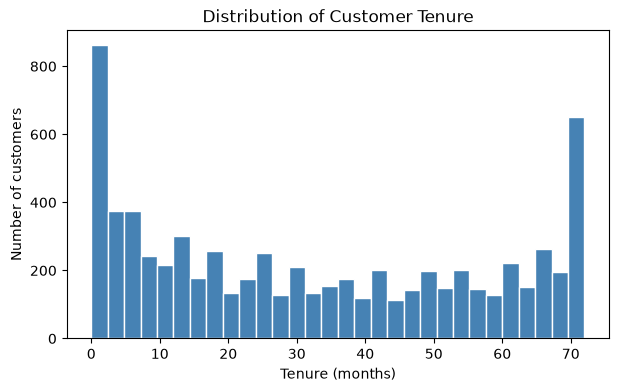

In [ ]:
# Task 12 — numerical feature 1: distribution plot
plt.figure(figsize=(7,4))
plt.hist(df_clean['tenure'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.title('Distribution of Customer Tenure')
plt.show()


**Observation:** _The `tenure` variable does not follow a standard bell-shaped distribution. Instead, it exhibits noticeable peaks at the two extreme ends. There is a substantial cluster of brand-new clients (with a tenure near zero) alongside another prominent grouping of highly retained customers (clustered around 72 months, which appears to be the maximum limit of the data collection). This roughly bimodal pattern indicates the presence of two separate customer segments: those who tend to leave shortly after signing up, and dedicated users who remain loyal to the company for several years._

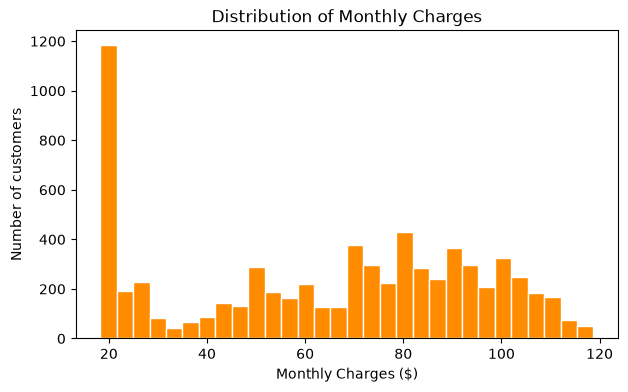

In [ ]:
# Task 12 — numerical feature 2: distribution plot
plt.figure(figsize=(7,4))
plt.hist(df_clean['MonthlyCharges'], bins=30, color='darkorange', edgecolor='white')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of customers')
plt.title('Distribution of Monthly Charges')
plt.show()


**Observation:** _The `MonthlyCharges` variable exhibits a broad range, spanning from roughly $18 to $120. A prominent spike is visible at the lower end (around $20), which most likely represents users subscribed exclusively to basic phone services without internet access. Additionally, there is a wider concentration of customers in the $70 to $100 bracket, presumably indicating those who pay for internet bundles along with various premium add-on features. Overall, the data does not show a severe skew; instead, it displays a multi-modal pattern rather than a simple, continuous curve._

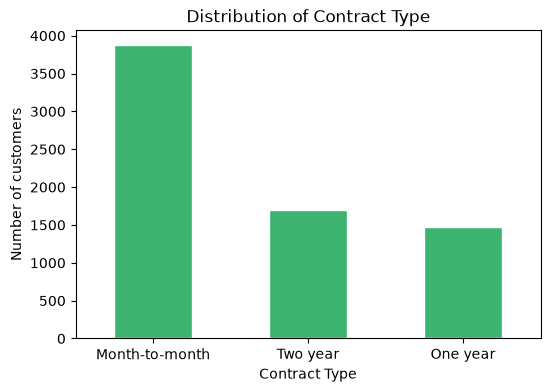

In [ ]:
# Task 12 — categorical feature 1: distribution plot
plt.figure(figsize=(6,4))
df_clean['Contract'].value_counts().plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.xlabel('Contract Type')
plt.ylabel('Number of customers')
plt.title('Distribution of Contract Type')
plt.xticks(rotation=0)
plt.show()


**Observation:** _The majority of the client base (roughly 55%, or 3,875 out of 7,043 customers) is currently subscribed to Month-to-month plans. In contrast, One year and Two year agreements account for much smaller proportions, making up approximately 21% and 24% respectively. Because users on monthly plans do not incur cancellation penalties and can leave freely, this skewed distribution provides crucial context for the deeper churn investigation coming up in Part 7._

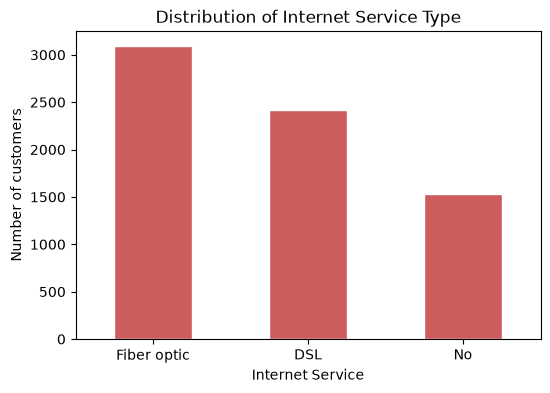

In [ ]:
# Task 12 — categorical feature 2: distribution plot
plt.figure(figsize=(6,4))
df_clean['InternetService'].value_counts().plot(kind='bar', color='indianred', edgecolor='white')
plt.xlabel('Internet Service')
plt.ylabel('Number of customers')
plt.title('Distribution of Internet Service Type')
plt.xticks(rotation=0)
plt.show()


**Observation:** _The most widely used internet connection among the customer base is Fiber optic (accounting for approximately 44%), with DSL coming in second (at about 34%). Meanwhile, roughly 22% of the users do not subscribe to any internet service. This distribution is highly relevant because Fiber optic plans generally incur the highest monthly fees, a factor that could strongly influence the churn patterns we will analyze later._

**Answer 13 (outliers / skew and possible explanation):** _The `TotalCharges` variable demonstrates a noticeable right-skew (with a skewness of roughly 0.96). This occurs because the total amount billed naturally compounds over time; highly loyal customers generate substantially larger lifetime charges compared to new sign-ups, which forms a long right tail instead of indicating actual erroneous outliers. On the other hand, `tenure` and `MonthlyCharges` exhibit very mild skewness (around 0.24 and -0.22, respectively) without any extreme anomaly values. Their variations simply capture real differences within the customer base—such as recent versus veteran subscribers, or basic versus premium plan users—rather than pointing to any data recording mistakes._

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [17]:
# Task 14 — churn counts and percentages
churn_counts = df_clean['Churn'].value_counts()
churn_pct = (df_clean['Churn'].value_counts(normalize=True) * 100).round(2)

churn_summary = pd.DataFrame({'Count': churn_counts, 'Percentage (%)': churn_pct})
print(churn_summary)


       Count  Percentage (%)
Churn                       
No      5174           73.46
Yes     1869           26.54


**Answer 14 (balanced or imbalanced?):** _The target variable exhibits a clear imbalance. Specifically, 5,174 users (approximately 73.5%) remained with the company ("No"), whereas only 1,869 users (around 26.5%) actually canceled their service ("Yes"). While not severely skewed, this presents a distinct 3:1 class distribution that we must account for._

**Answer 15 (why imbalance might matter later):** _When training a predictive model on such skewed data, overall accuracy becomes an unreliable performance measure. A model could simply guess "No churn" for every single instance and still appear to be ~73% accurate. Furthermore, because the algorithm is exposed to significantly fewer actual churn events, it might have difficulty identifying the underlying traits of the customers who leave. Consequently, when evaluating future models, we cannot rely on accuracy alone; instead, we must utilize metrics like precision, recall, and the F1-score to properly assess how well it detects the minority ("Yes") class._

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


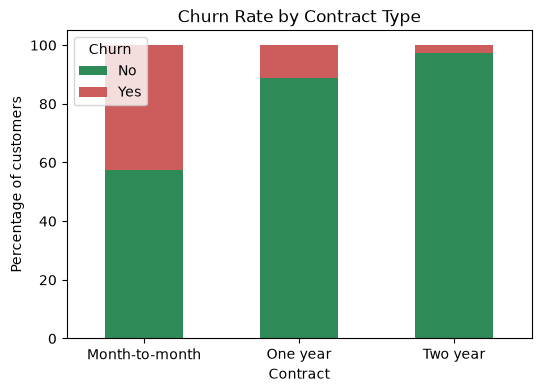

In [18]:
# Task 16 — categorical feature 1 vs Churn
ct_contract = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
print(ct_contract.round(2))

ct_contract.plot(kind='bar', stacked=True, figsize=(6,4), color=['seagreen','indianred'])
plt.ylabel('Percentage of customers')
plt.title('Churn Rate by Contract Type')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()


**Observation:** _There is a dramatic decrease in customer attrition as the duration of the contract gets longer._ 

**Evidence:** _Subscribers on month-to-month plans experience a high churn rate of roughly 42.7%. This drops significantly to about 11.3% for those on one-year plans, and plummets to a mere 2.8% for customers bound by two-year agreements._ 

**Possible Explanation:** _Extended contracts typically introduce switching barriers, such as early termination penalties or term-dependent discounts, which discourage leaving. Moreover, these long-term plans naturally appeal to users who are already highly satisfied and intend to stay. Thus, both the financial disincentives to cancel and the users' inherent loyalty work together to minimize churn._

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


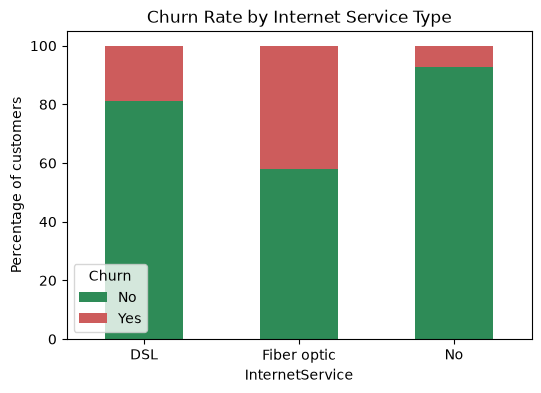

In [19]:
# Task 16 — categorical feature 2 vs Churn
ct_internet = pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index') * 100
print(ct_internet.round(2))

ct_internet.plot(kind='bar', stacked=True, figsize=(6,4), color=['seagreen','indianred'])
plt.ylabel('Percentage of customers')
plt.title('Churn Rate by Internet Service Type')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()


**Observation:** _Users subscribed to Fiber optic internet exhibit a significantly higher attrition rate compared to those using DSL or lacking internet service entirely._ 

**Evidence:** _The data reveals a churn rate of approximately 41.9% for Fiber optic users, which stands in stark contrast to the ~19.0% rate for DSL subscribers and a mere ~7.4% for clients without internet access._ 

**Possible Explanation:** _As noted previously, Fiber optic packages represent the most costly service tier. This elevated expense, coupled with the likelihood of having multiple high-speed competitor options, likely increases price sensitivity among these users. Consequently, they are much faster to change providers if they experience any dissatisfaction with the pricing or the overall quality of the connection._

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


C:\Users\TECH ZONE\AppData\Local\Temp\ipykernel_10604\2100328539.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_clean, palette=['seagreen','indianred'])


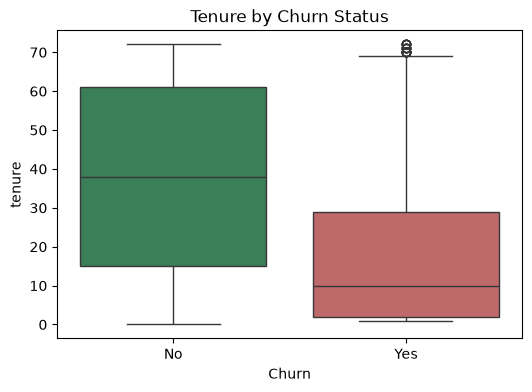

In [20]:
# Task 17 — numerical feature 1 vs Churn
print(df_clean.groupby('Churn')['tenure'].describe())

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df_clean, palette=['seagreen','indianred'])
plt.title('Tenure by Churn Status')
plt.show()


**Observation:** _Client attrition is heavily concentrated among users with significantly shorter account histories compared to those who remain active._

**Evidence:** _The data indicates that the mean tenure for individuals who leave is approximately 18.0 months, which is essentially half of the ~37.6 month average observed in retained users. Additionally, the boxplot clearly illustrates that both the median and the interquartile range for the churned cohort are positioned substantially lower than those of the active subscriber base._

**Possible Explanation:** _This behavior aligns with the classic "early risk" trend frequently seen in subscription-based models. Recently acquired customers lack established brand loyalty, ingrained usage habits, and financial sunk costs. Consequently, if their early interactions with the service fail to satisfy their initial expectations, they are highly prone to dropping out prematurely._

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


C:\Users\TECH ZONE\AppData\Local\Temp\ipykernel_10604\2296902077.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, palette=['seagreen','indianred'])


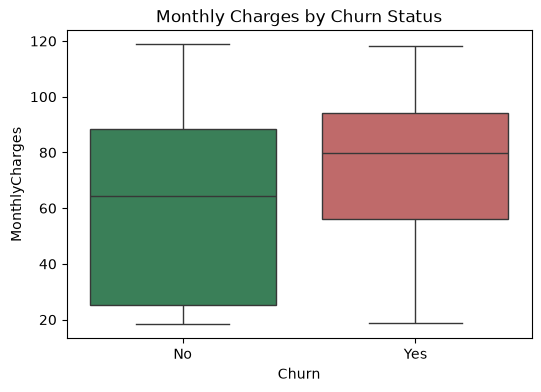

In [21]:
# Task 17 — numerical feature 2 vs Churn
print(df_clean.groupby('Churn')['MonthlyCharges'].describe())

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean, palette=['seagreen','indianred'])
plt.title('Monthly Charges by Churn Status')
plt.show()


**Observation:** _Clients who end up canceling their service generally face steeper monthly bills._

**Evidence:** _The data shows that the mean `MonthlyCharges` for individuals who left the company is roughly $74.44, which is significantly higher than the $61.27 average for those who stayed. Furthermore, the boxplot clearly illustrates an upward shift in the distribution of charges for the churned cohort._

**Possible Explanation:** _This aligns seamlessly with our earlier insights regarding contract types and internet services. Subscribers who incur higher costs—frequently those on month-to-month fiber optic plans—might feel that the service quality does not justify the premium price. This perceived lack of value heightens their price sensitivity, ultimately making them much more likely to defect to a competitor._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.248         0.826
MonthlyCharges   0.248           1.000         0.651
TotalCharges     0.826           0.651         1.000


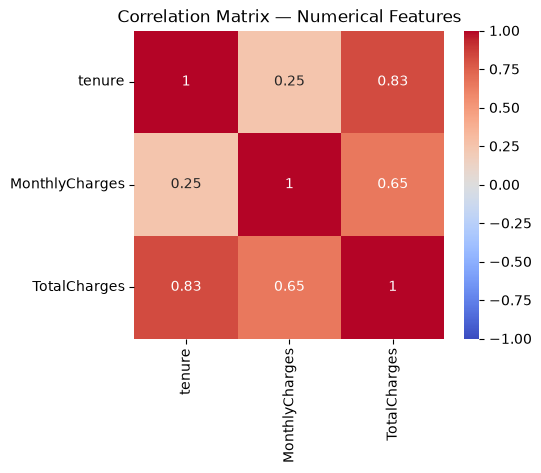

In [22]:
# Task 18 — correlation matrix and heatmap
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df_clean[num_cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix — Numerical Features')
plt.show()


**Answer 18 (most correlated pairs):** _The strongest relationship in the numerical data is between `tenure` and `TotalCharges`, showing a highly positive correlation coefficient of approximately 0.83. This is followed by `MonthlyCharges` and `TotalCharges`, which exhibit a moderately strong correlation (r ≈ 0.65). In contrast, the relationship between `tenure` and `MonthlyCharges` is quite weak (r ≈ 0.25)._

**Answer 19 (correlation vs. causation; potential problems):** _In this specific dataset, the high correlation does not indicate true causation. The strong link between `TotalCharges` and `tenure` is primarily a mathematical byproduct, because a customer's total bill naturally grows as their time with the company extends (essentially, `TotalCharges` ≈ `tenure` × `MonthlyCharges`). Leaving these highly redundant features in the dataset could cause issues for future predictive models. Since `TotalCharges` provides almost no new insight beyond what is already captured by `tenure` and `MonthlyCharges`, keeping it introduces severe multicollinearity. This can destabilize the coefficients in linear models or simply add unnecessary noise to tree-based algorithms without offering any real boost to predictive performance._

---